Based on what we learnt during P1, create a 300x300 RGB image with three equal width columns that follow the RGB colours. Next, load the `star_500.png` and use to modify the first image by embedding a **star** in it. Finally, show the original image, `star_500` image, the image with the embedded yellow start and a grayscale version of it. Final results should like as follows:

![](E1_result.png)

**Useful Tips:**

*   rgb2gray returns a float image in [0, 1] range, you might want to change it back to [0, 255] range. Simple multiplication should do.

In [9]:
import numpy as np
from skimage import io
from skimage import img_as_ubyte, img_as_float
from skimage.transform import resize
from skimage.color import rgb2gray
from matplotlib import pyplot as plt

STAR_MASK_PATH = 'star_500.jpeg'  # update path if needed


(300, 300, 3)


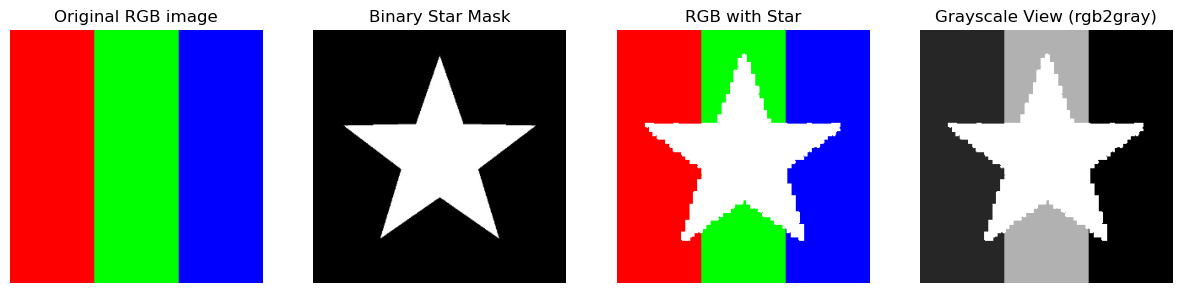

In [11]:
three_bars = np.zeros((300,300,3),dtype=np.uint8)

three_bars[:,:100,0] = 255
three_bars[:,100:200,1] = 255
three_bars[:,200:,2] = 255

star = io.imread(STAR_MASK_PATH)
star_resize = resize(star, (300,300))
print(star_resize.shape)
mask = star_resize[:,:,:]>0
mask = np.max(mask, axis=2)
new_star = three_bars.copy()
new_star[mask] = 255
new_star_gray = img_as_ubyte(rgb2gray(new_star))


fig,axs = plt.subplots(nrows=1,ncols=4, figsize=(15,15))

ax = axs[0]
ax.imshow(three_bars)
ax.axis('off')
ax.set_title('Original RGB image')

ax = axs[1]
ax.imshow(star_resize)
ax.axis('off')
ax.set_title('Binary Star Mask')

ax = axs[2]
ax.imshow(new_star)
ax.axis('off')
ax.set_title('RGB with Star')

ax = axs[3]
ax.imshow(new_star_gray, cmap = 'gray')
ax.axis('off')
ax.set_title('Grayscale View (rgb2gray)')

plt.show()